# Report Figures
Generate plots and tables for the E3 submission.


In [1]:
# === ENVIRONMENT & FILEPATH SETUP ===
import os
import sys

codebase_path = "../"
if codebase_path not in sys.path:
    sys.path.insert(0, codebase_path)

# Clear src modules to allow reloading
for key in list(sys.modules.keys()):
    if key.startswith("src"):
        del sys.modules[key]

DATA_DIR = f"{codebase_path}data"
CACHE_DIR = f"{codebase_path}output/cache"
MODELS_DIR = f"{codebase_path}output/models"
ARTIFACTS_DIR = f"{codebase_path}artifacts"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load experiment summary
summary = pd.read_csv(f"{ARTIFACTS_DIR}/experiment_summary.csv")
summary

,Experiment_ID,Method_Category,Features,K-Fold,CV_Reward_0.85,CV_Avg_Performance,CV_Avg_Cost,Model_Distribution,Public_Kaggle_Score
0,Oracle_Upper_Bound,Baseline,-,-,0.6731,0.8083,0.0072,Optimal Routing,NaN
1,ridge,regression,w2v_size100_win5,5,0.4614,0.5696,0.0117,"{'Model_K': 4630, 'Model_H': 1874, 'Model_B': ...",NaN
2,ridge,regression,dense_all-MiniLM-L6-v2,5,0.4611,0.5709,0.0124,"{'Model_K': 3257, 'Model_H': 1904, 'Model_F': ...",NaN
3,ridge,regression,svd_comp500_tfidf5000_ng1-1,5,0.4578,0.5662,0.0121,"{'Model_K': 3491, 'Model_H': 1803, 'Model_F': ...",NaN
4,ridge,regression,meta_len1_code1_math1,5,0.4555,0.5675,0.0138,"{'Model_K': 7792, 'Model_H': 1985, 'Model_D': ...",NaN
...,...,...,...,...,...,...,...,...,...
69,xgboost,regression,svd_comp1000_tfidf30000_ng1-3,10,0.4303,0.5345,0.0123,"{'Model_K': 2358, 'Model_H': 1380, 'Model_F': ...",NaN
70,xgboost,cost_sensitive,dense_Qwen-Qwen3-Embedding-8B,10,0.4555,0.5758,0.0174,"{'Model_K': 5386, 'Model_H': 1846, 'Model_F': ...",NaN
71,lightgbm,classification,tfidf_max30000_ng1-3,10,0.4476,0.5323,0.0025,"{'Model_K': 8079, 'Model_C': 762, 'Model_D': 5...",NaN
72,lightgbm,cost_sensitive,tfidf_max30000_ng1-3,10,0.4470,0.5778,0.0227,"{'Model_K': 4583, 'Model_H': 2314, 'Model_F': ...",NaN


In [4]:
summary = summary.drop([0, 52])
summary

,Experiment_ID,Method_Category,Features,K-Fold,CV_Reward_0.85,CV_Avg_Performance,CV_Avg_Cost,Model_Distribution,Public_Kaggle_Score
1,ridge,regression,w2v_size100_win5,5,0.4614,0.5696,0.0117,"{'Model_K': 4630, 'Model_H': 1874, 'Model_B': ...",NaN
2,ridge,regression,dense_all-MiniLM-L6-v2,5,0.4611,0.5709,0.0124,"{'Model_K': 3257, 'Model_H': 1904, 'Model_F': ...",NaN
3,ridge,regression,svd_comp500_tfidf5000_ng1-1,5,0.4578,0.5662,0.0121,"{'Model_K': 3491, 'Model_H': 1803, 'Model_F': ...",NaN
4,ridge,regression,meta_len1_code1_math1,5,0.4555,0.5675,0.0138,"{'Model_K': 7792, 'Model_H': 1985, 'Model_D': ...",NaN
5,lightgbm,regression,tfidf_max5000_ng1-1,5,0.4553,0.5634,0.0121,"{'Model_K': 3625, 'Model_H': 1648, 'Model_F': ...",NaN
...,...,...,...,...,...,...,...,...,...
69,xgboost,regression,svd_comp1000_tfidf30000_ng1-3,10,0.4303,0.5345,0.0123,"{'Model_K': 2358, 'Model_H': 1380, 'Model_F': ...",NaN
70,xgboost,cost_sensitive,dense_Qwen-Qwen3-Embedding-8B,10,0.4555,0.5758,0.0174,"{'Model_K': 5386, 'Model_H': 1846, 'Model_F': ...",NaN
71,lightgbm,classification,tfidf_max30000_ng1-3,10,0.4476,0.5323,0.0025,"{'Model_K': 8079, 'Model_C': 762, 'Model_D': 5...",NaN
72,lightgbm,cost_sensitive,tfidf_max30000_ng1-3,10,0.4470,0.5778,0.0227,"{'Model_K': 4583, 'Model_H': 2314, 'Model_F': ...",NaN


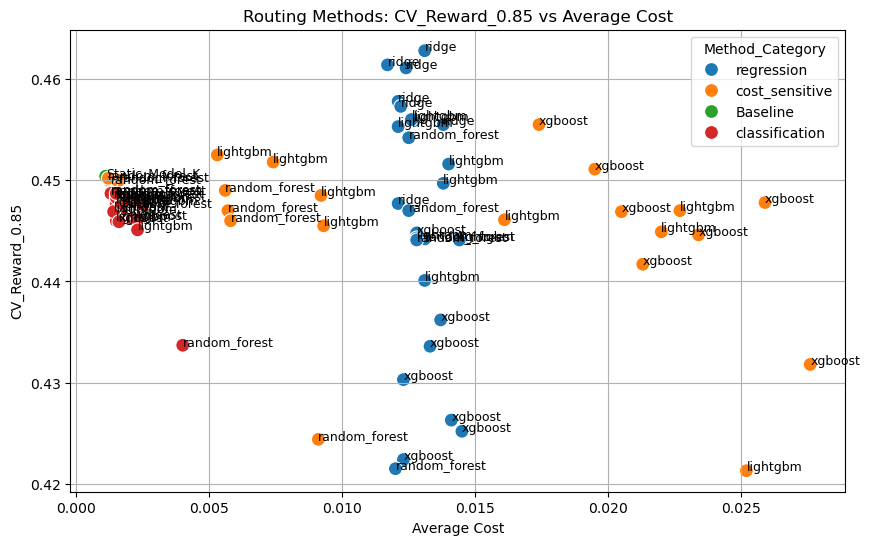

In [5]:
# Plot 1: Performance vs Cost Tradeoff
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary, x='CV_Avg_Cost', y='CV_Reward_0.85', hue='Method_Category', s=100)

for i, row in summary.iterrows():
    plt.text(row['CV_Avg_Cost'], row['CV_Reward_0.85'], row['Experiment_ID'], fontsize=9)

plt.title("Routing Methods: CV_Reward_0.85 vs Average Cost")
plt.xlabel("Average Cost")
plt.ylabel("CV_Reward_0.85")
plt.grid(True)
# plt.savefig(f"{ARTIFACTS_DIR}/perf_vs_cost.png")
plt.show()

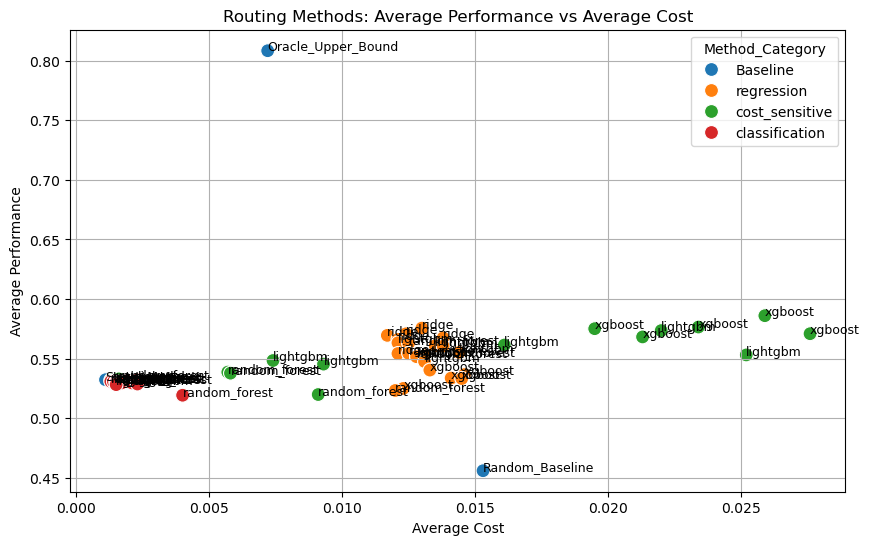

In [3]:
# Plot 1: Performance vs Cost Tradeoff
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary, x='CV_Avg_Cost', y='CV_Avg_Performance', hue='Method_Category', s=100)

for i, row in summary.iterrows():
    plt.text(row['CV_Avg_Cost'], row['CV_Avg_Performance'], row['Experiment_ID'], fontsize=9)

plt.title("Routing Methods: Average Performance vs Average Cost")
plt.xlabel("Average Cost")
plt.ylabel("Average Performance")
plt.grid(True)
# plt.savefig(f"{ARTIFACTS_DIR}/perf_vs_cost.png")
plt.show()

In [ ]:
# Plot 2: Total Reward Comparison
summary_sorted = summary.sort_values(by='CV_Reward_0.85', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_sorted, x='Experiment_ID', y='CV_Reward_0.85')
plt.xticks(rotation=45, ha='right')
plt.title("Comparison of Overall Reward_0.85 by Method")
plt.ylim(0, 1.0)
plt.grid(axis='y')
# plt.savefig(f"{ARTIFACTS_DIR}/reward_comparison.png", bbox_inches='tight')
plt.show()